# Data for the bivariate analysis: commodity prices and tree cover loss

This notebook builds the three files we use for the bivariate analysis and saves them in `data/processed/`:

| File | Unit of observation | Content |
|---|---|---|
| `exposure_weights.csv` | country × commodity | baseline (1996–2000) production of soybeans, palm oil and beef, its value, and each commodity's share in the country's basket |
| `price_index_panel.csv` | country × year | country-specific commodity price index: world real prices weighted by the baseline shares |
| `analysis_panel.csv` | country × year | tree cover loss + price index (current and lagged) + world prices + exposure, ready for scatter plots and correlations |

**Idea.** World prices are the same for every country. A soy boom should only matter for countries that produce soy.
We therefore weight each world price by how much the country produced of that commodity **before** our sample starts (1996–2000),
so that the weights are not themselves affected by deforestation during 2001–2025.

*Inputs: `deforestation_panel.csv` and `commodity_prices_annual.csv` (data/processed), FAOSTAT production via Our World in Data (data/raw/crops).*

## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Data is loaded from GitHub with URL links, so the notebook runs on any computer.
# Output files are written locally, then pushed to GitHub.
BASE_URL = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/"
RAW = BASE_URL + "raw/crops/"
PROCESSED = BASE_URL + "processed/"
PROCESSED_OUT = "../data/processed/"
FIGURES = "../figures/"

BASELINE = (1996, 2000)   # pre-sample years used for the weights

SOURCE = "Sources: Global Forest Watch; FAOSTAT via Our World in Data; World Bank Pink Sheet"


def add_source(fig, text=SOURCE):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")


# commodity name in the price file -> (production file, production column, factor to convert the price to $/tonne)
COMMODITIES = {
    "Soybeans": ("soybean-production.csv", "Soybeans - Production (tonnes)", 1),
    "Palm oil": ("palm-oil-production.csv", "Palm oil - Production (tonnes)", 1),
    "Beef":     ("beef-and-buffalo-meat-production-tonnes.csv", "Beef and buffalo meat - Production (tonnes)", 1000),  # $/kg -> $/t
}

## 1. Load the inputs

### 1.1 Deforestation panel and world prices

In [2]:
defor = pd.read_csv(PROCESSED + "deforestation_panel.csv")
countries = defor[["iso3", "country", "region", "extent_2000_ha"]].drop_duplicates()
print("Deforestation panel:", defor.shape, "|", countries.shape[0], "countries,", defor.year.min(), "-", defor.year.max())

prices = pd.read_csv(PROCESSED + "commodity_prices_annual.csv")
prices = prices[prices["commodity"].isin(COMMODITIES)].copy()
prices["price_real_t"] = prices["price_real"] * prices["commodity"].map({k: v[2] for k, v in COMMODITIES.items()})
prices["log_price_real"] = np.log(prices["price_real_t"])
prices[["commodity", "unit"]].drop_duplicates()

Deforestation panel: (1575, 11) | 63 countries, 2001 - 2025


,commodity,unit
3,Beef,($/kg)
25,Palm oil,($/mt)
37,Soybeans,($/mt)


### 1.2 Production by country (FAOSTAT via Our World in Data)

We keep only the countries of our tropical sample and stack the three commodities in one long table.

In [3]:
prod = []
for commodity, (file, col, _) in COMMODITIES.items():
    p = pd.read_csv(RAW + file).rename(columns={"Code": "iso3", "Year": "year", col: "production_t"})
    p = p[p["iso3"].isin(countries["iso3"])]
    p["commodity"] = commodity
    prod.append(p[["iso3", "commodity", "year", "production_t"]])
prod = pd.concat(prod, ignore_index=True)

# number of sample countries with at least one baseline observation
prod[prod.year.between(*BASELINE)].groupby("commodity")["iso3"].nunique()

commodity
Beef        62
Palm oil    36
Soybeans    43
Name: iso3, dtype: int64

## 2. Exposure weights (country × commodity)

For each country and commodity:
- `prod_base_t`: average production over 1996–2000. A country that does not appear in the file for that commodity produced nothing: we set it to 0.
- `value_base_usd`: baseline production × average real world price over 1996–2000. This puts tonnes of soy, palm oil and beef on the same scale (dollars).
- `share`: the commodity's share in the country's baseline value of the three commodities (sums to 1 within a country).
- `value_per_forest_ha`: total baseline value divided by the 2000 forest extent, to measure *how much* a country is exposed, not only *to what*.

South Sudan did not exist before 2011, so it has no baseline production: its weights are missing.

In [4]:
base_prod = (prod[prod.year.between(*BASELINE)]
             .groupby(["iso3", "commodity"])["production_t"].mean()
             .rename("prod_base_t").reset_index())
base_price = (prices[prices.year.between(*BASELINE)]
              .groupby("commodity")["price_real_t"].mean()
              .rename("price_base_usd_t").reset_index())

# full grid country x commodity, so that non-producers get an explicit 0
grid = pd.MultiIndex.from_product([countries["iso3"], list(COMMODITIES)], names=["iso3", "commodity"]).to_frame(index=False)
weights = grid.merge(base_prod, how="left").merge(base_price, how="left")

has_data = weights.groupby("iso3")["prod_base_t"].transform(lambda s: s.notna().any())
weights.loc[has_data, "prod_base_t"] = weights.loc[has_data, "prod_base_t"].fillna(0)

weights["value_base_usd"] = weights["prod_base_t"] * weights["price_base_usd_t"]
total = weights.groupby("iso3")["value_base_usd"].transform("sum", min_count=1)
weights["share"] = weights["value_base_usd"] / total
weights = weights.merge(countries, on="iso3")
weights["value_per_forest_ha"] = total / weights["extent_2000_ha"]

print("Countries without baseline data:", weights.loc[weights.share.isna(), "iso3"].unique())
weights.pivot(index="iso3", columns="commodity", values="share").round(2).sort_values("Palm oil", ascending=False).head(10)

Countries without baseline data: <StringArray>
['SSD']
Length: 1, dtype: str


commodity,Beef,Palm oil,Soybeans
iso3,,,
MYS,0.01,0.99,0.00
PNG,0.03,0.97,0.00
GNQ,0.04,0.96,0.00
SLB,0.07,0.93,0.00
LBR,0.08,0.89,0.03
CIV,0.22,0.78,0.00
COG,0.24,0.76,0.00
COD,0.23,0.75,0.02
SLE,0.26,0.74,0.00


Dominant commodity per country (largest baseline share):

In [5]:
main = weights.dropna(subset=["share"]).sort_values("share").groupby("iso3").tail(1)
main["commodity"].value_counts()

commodity
Beef        49
Palm oil    12
Soybeans     1
Name: count, dtype: int64

In [6]:
cols_w = ["iso3", "country", "region", "commodity", "prod_base_t", "price_base_usd_t",
          "value_base_usd", "share", "value_per_forest_ha"]
weights[cols_w].sort_values(["iso3", "commodity"]).to_csv(PROCESSED_OUT + "exposure_weights.csv", index=False)
print("Exported exposure_weights.csv:", weights[cols_w].shape)

Exported exposure_weights.csv: (189, 9)


## 3. Country-specific price index (country × year)

$$\text{price\_index}_{ct} = \sum_k \text{share}_{ck} \times \log p_{kt}$$

where $p_{kt}$ is the real world price of commodity $k$ in year $t$. The weights are fixed at their baseline values,
so the index only moves because world prices move. We build it from 2000 so that the one-year lag exists for 2001.

In [7]:
years = range(2000, defor.year.max() + 1)
logp = prices[prices.year.isin(years)][["commodity", "year", "log_price_real"]]

idx = weights[["iso3", "commodity", "share"]].merge(logp, on="commodity")
idx["contrib"] = idx["share"] * idx["log_price_real"]
price_index = (idx.groupby(["iso3", "year"])["contrib"].sum(min_count=1)
               .rename("price_index").reset_index()
               .sort_values(["iso3", "year"]))
price_index["price_index_lag1"] = price_index.groupby("iso3")["price_index"].shift(1)
price_index["d_price_index"] = price_index["price_index"] - price_index["price_index_lag1"]

price_index.to_csv(PROCESSED_OUT + "price_index_panel.csv", index=False)
print("Exported price_index_panel.csv:", price_index.shape)
price_index.head()

Exported price_index_panel.csv: (1638, 5)


,iso3,year,price_index,price_index_lag1,d_price_index
0,AGO,2000,7.531661,NaN,NaN
1,AGO,2001,7.635749,7.531661,0.104088
2,AGO,2002,7.700480,7.635749,0.064731
3,AGO,2003,7.676787,7.700480,-0.023692
4,AGO,2004,7.813108,7.676787,0.136321


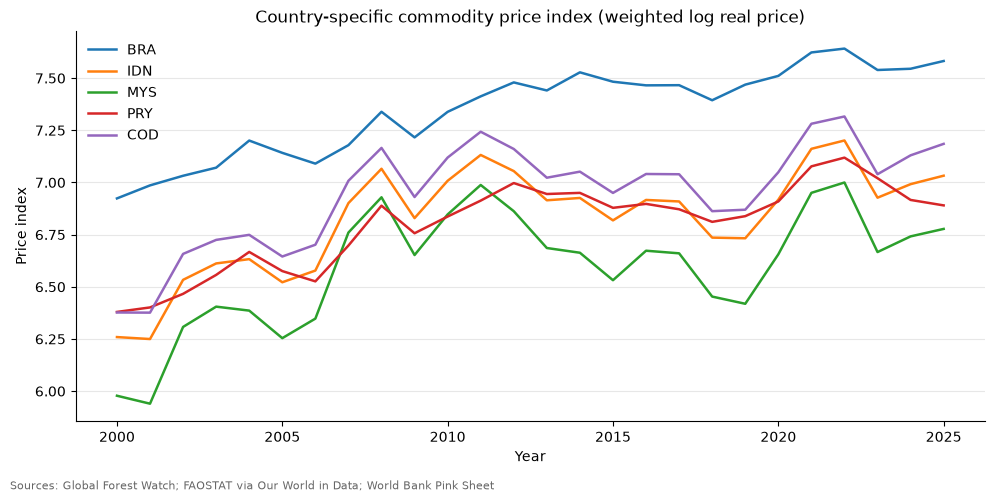

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for iso in ["BRA", "IDN", "MYS", "PRY", "COD"]:
    d = price_index[price_index.iso3 == iso]
    ax.plot(d["year"], d["price_index"], label=iso, linewidth=1.8)
ax.set_title("Country-specific commodity price index (weighted log real price)")
ax.set_xlabel("Year")
ax.set_ylabel("Price index")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 4. Analysis panel (country × year)

We add to the deforestation panel:
- the price index, its one-year lag and its change (`price_index`, `price_index_lag1`, `d_price_index`);
- the world log real price of each commodity, current and lagged (same for every country, useful for simple scatter plots);
- the baseline shares and the exposure intensity (`value_per_forest_ha`), which we can use to split the sample.

In [9]:
wide_p = (logp.pivot(index="year", columns="commodity", values="log_price_real")
          .rename(columns=lambda c: "log_p_" + c.lower().replace(" ", "_")))
wide_p = wide_p.join(wide_p.shift(1).add_suffix("_lag1")).reset_index()

wide_w = (weights.pivot(index="iso3", columns="commodity", values="share")
          .rename(columns=lambda c: "share_" + c.lower().replace(" ", "_")))
wide_w["value_per_forest_ha"] = weights.groupby("iso3")["value_per_forest_ha"].first()
wide_w = wide_w.reset_index()

panel = (defor.merge(price_index, on=["iso3", "year"], how="left")
              .merge(wide_p, on="year", how="left")
              .merge(wide_w, on="iso3", how="left")
              .sort_values(["iso3", "year"]))

panel.to_csv(PROCESSED_OUT + "analysis_panel.csv", index=False)
print("Exported analysis_panel.csv:", panel.shape)
print("Same number of rows as the deforestation panel:", len(panel) == len(defor))
panel.isna().sum()[lambda s: s > 0]

Exported analysis_panel.csv: (1575, 24)
Same number of rows as the deforestation panel: True


price_index            25
price_index_lag1       25
d_price_index          25
share_beef             25
share_palm_oil         25
share_soybeans         25
value_per_forest_ha    25
dtype: int64

### 4.1 First look: correlations with the tree cover loss rate

In [10]:
cols = ["log_loss_rate", "log_agri_loss_rate", "price_index", "price_index_lag1", "d_price_index",
        "log_p_soybeans_lag1", "log_p_palm_oil_lag1", "log_p_beef_lag1"]
panel[cols].corr().loc[["log_loss_rate", "log_agri_loss_rate"]].round(2).T

,log_loss_rate,log_agri_loss_rate
log_loss_rate,1.00,0.83
log_agri_loss_rate,0.83,1.00
price_index,-0.08,0.00
price_index_lag1,-0.07,0.01
d_price_index,-0.05,-0.03
log_p_soybeans_lag1,0.20,0.12
log_p_palm_oil_lag1,0.16,0.11
log_p_beef_lag1,0.26,0.12


These are raw correlations: they mix differences *between* countries with changes *over time* within a country.
The bivariate analysis should therefore also look at within-country variation (demeaning by country), before moving to the panel regression with country and year fixed effects.

## 5. Bivariate analysis: the price shock X and tree cover loss

We now use the price shock built in `david.com.price.ipynb` (section *Building X*), saved in `shock_panel.csv`:

$$X_{it} = \sum_{c} \log(1 + E_{ic}) \times \tilde p_{ct}$$

where $E_{ic}$ is the 1996–2000 production value of commodity $c$ per hectare of forest in 2000 and $\tilde p_{ct}$ is the log real world price minus its 1996–2000 average. Unlike the price index of section 3, X also measures *how much* a country is exposed, not only *to what*. We relate the loss rate in year $t$ to the shock of the previous year, $X_{i,t-1}$.

We look at the relationship in three ways, from the rawest to the most demanding:
1. **Raw**: all country-years pooled. Mixes differences between countries with changes over time.
2. **Within**: after removing each country's average and each year's average (what country and year fixed effects do).
3. **Within, without trends**: also removing each country's own linear trend, or using year-to-year changes.

In [11]:
shock = pd.read_csv(PROCESSED + "shock_panel.csv")
print(shock.shape, "|", shock.iso3.nunique(), "countries,", shock.year.min(), "-", shock.year.max())

OUTCOMES = {"log_loss_rate": "Tree cover loss rate (log)", "log_agri_loss_rate": "Agricultural loss rate (log)"}
REGION_COLORS = {"Latin America & Caribbean": "#2a78d6", "Africa": "#eda100", "Asia-Pacific": "#1baf7a"}
shock[["shock", "shock_lag1"] + list(OUTCOMES)].describe().round(2)

(1550, 13) | 62 countries, 2001 - 2025


,shock,shock_lag1,log_loss_rate,log_agri_loss_rate
count,1550.00,1550.00,1550.00,1550.00
mean,1.76,1.64,-1.02,-1.91
std,1.44,1.43,1.08,1.57
min,-2.08,-2.08,-5.51,-7.30
25%,0.60,0.53,-1.65,-2.78
50%,1.42,1.29,-0.88,-1.50
75%,2.62,2.52,-0.30,-0.76
max,7.55,7.55,1.72,0.98


### 5.1 Raw relationship

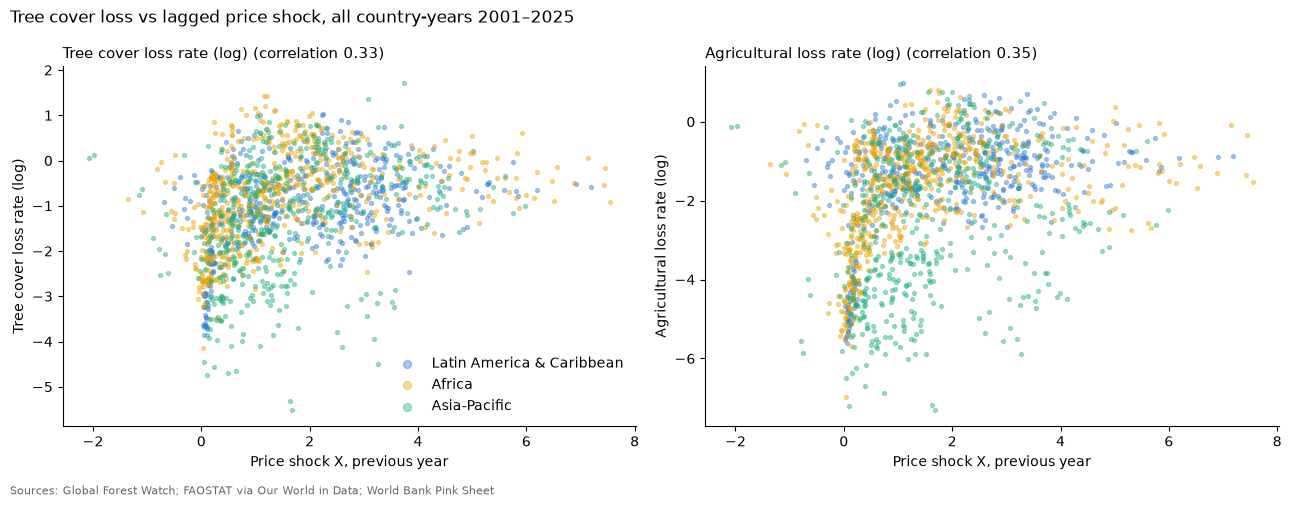

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, (y, label) in zip(axes, OUTCOMES.items()):
    for region, col in REGION_COLORS.items():
        d = shock[shock.region == region]
        ax.scatter(d["shock_lag1"], d[y], s=8, alpha=0.4, color=col, label=region)
    r = shock[y].corr(shock["shock_lag1"])
    ax.set_title(f"{label} (correlation {r:.2f})", loc="left", fontsize=11)
    ax.set_xlabel("Price shock X, previous year")
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, markerscale=2)
fig.suptitle("Tree cover loss vs lagged price shock, all country-years 2001–2025", x=0.01, ha="left")
add_source(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES + "bivariate_raw.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.2 Within countries

To compare each country with itself, we remove from every variable its country average and its year average (two-way demeaning, the same variation that a regression with country and year fixed effects uses). In the third version we also remove each country's own linear trend.

To make the cloud readable, the binned scatter groups the observations into 20 bins of equal size along the x-axis and plots the average of each bin.

In [13]:
def residualize(df, col, trend=False):
    """Residual of col after country and year averages (and a linear trend per country)."""
    formula = f"{col} ~ C(iso3) + C(year)" + (" + C(iso3):t" if trend else "")
    with warnings.catch_warnings():
        # with trends, the country trends and the year averages share one column: statsmodels warns,
        # but the residuals are unique
        warnings.simplefilter("ignore")
        return smf.ols(formula, data=df.assign(t=df.year - df.year.min())).fit().resid


within = shock[["iso3", "year", "region"]].copy()
for col in ["shock_lag1"] + list(OUTCOMES):
    within[col] = residualize(shock, col)
    within[col + "_detr"] = residualize(shock, col, trend=True)

# year-to-year changes (first differences)
fd = shock.sort_values(["iso3", "year"]).copy()
for col in ["shock_lag1"] + list(OUTCOMES):
    fd["d_" + col] = fd.groupby("iso3")[col].diff()
fd = fd.dropna(subset=["d_shock_lag1"])

summary = pd.DataFrame({
    "raw": [shock[y].corr(shock["shock_lag1"]) for y in OUTCOMES],
    "within (country + year)": [within[y].corr(within["shock_lag1"]) for y in OUTCOMES],
    "within, country trends removed": [within[y + "_detr"].corr(within["shock_lag1_detr"]) for y in OUTCOMES],
    "year-to-year changes": [fd["d_" + y].corr(fd["d_shock_lag1"]) for y in OUTCOMES],
}, index=list(OUTCOMES.values())).T
summary.round(2)

,Tree cover loss rate (log),Agricultural loss rate (log)
raw,0.33,0.35
within (country + year),-0.24,-0.26
"within, country trends removed",-0.02,-0.08
year-to-year changes,-0.06,-0.07


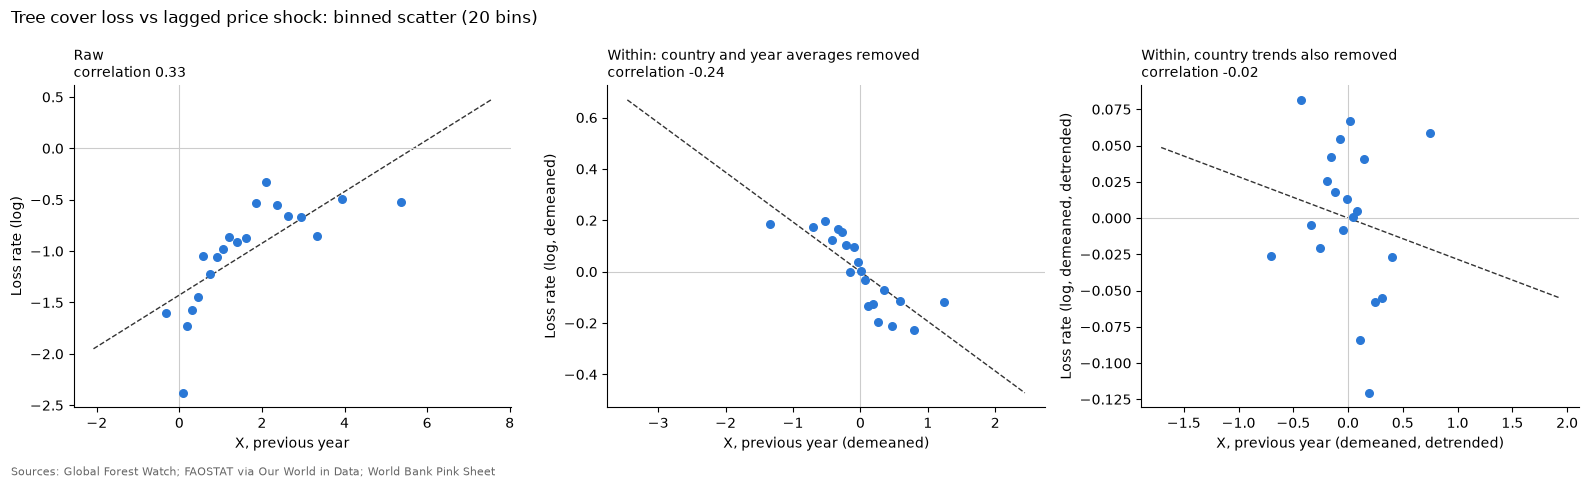

In [14]:
def binscatter(ax, x, y, bins=20, color="#2a78d6"):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    d["bin"] = pd.qcut(d["x"], bins, labels=False, duplicates="drop")
    b = d.groupby("bin")[["x", "y"]].mean()
    slope, intercept = np.polyfit(d["x"], d["y"], 1)
    ax.scatter(b["x"], b["y"], color=color, s=30, zorder=3)
    xs = np.linspace(d["x"].min(), d["x"].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="#333333", linewidth=1, linestyle="--")
    ax.axhline(0, color="#cccccc", linewidth=0.8)
    ax.axvline(0, color="#cccccc", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    return d["x"].corr(d["y"])


y = "log_loss_rate"
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
panels = [
    (shock["shock_lag1"], shock[y], "Raw", "X, previous year", "Loss rate (log)"),
    (within["shock_lag1"], within[y], "Within: country and year averages removed", "X, previous year (demeaned)", "Loss rate (log, demeaned)"),
    (within["shock_lag1_detr"], within[y + "_detr"], "Within, country trends also removed", "X, previous year (demeaned, detrended)", "Loss rate (log, demeaned, detrended)"),
]
for ax, (xv, yv, title, xl, yl) in zip(axes, panels):
    r = binscatter(ax, xv, yv)
    ax.set_title(f"{title}\ncorrelation {r:.2f}", loc="left", fontsize=10)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
fig.suptitle("Tree cover loss vs lagged price shock: binned scatter (20 bins)", x=0.01, ha="left")
add_source(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES + "bivariate_within.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.3 Why does the sign flip? Trends in exposed countries

The shock X grows over time in exposed countries, because world prices were mostly above their 1996–2000 level after 2003. If the most exposed countries also had a *falling* loss rate for other reasons (policies, the end of a frontier, ...), the within comparison picks up these two opposite trends, not the effect of prices. We check this by comparing, for each country, the trend of its loss rate with its average shock.

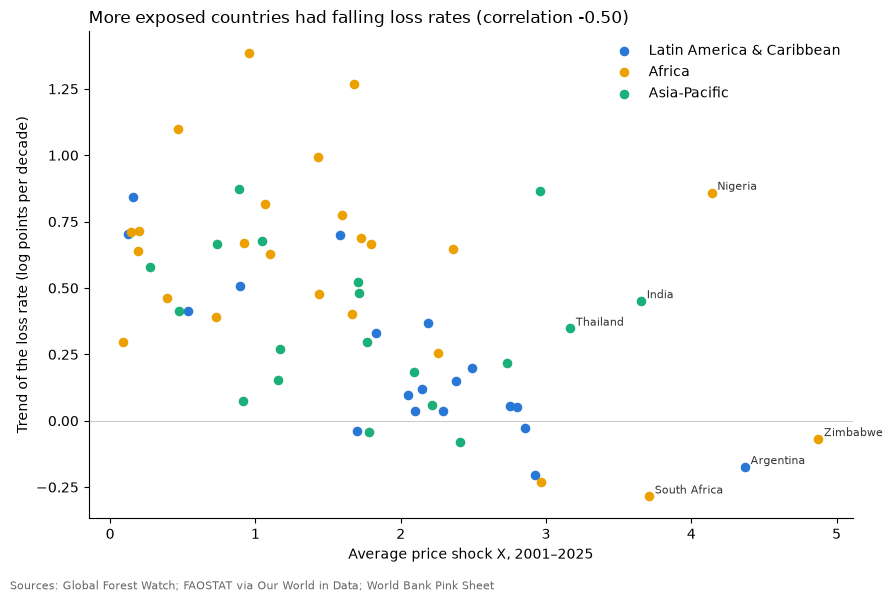

In [15]:
trend = (shock.groupby(["iso3", "country", "region"])
              .apply(lambda g: pd.Series({
                  "loss_trend": np.polyfit(g["year"], g["log_loss_rate"], 1)[0] * 10,  # change per decade
                  "mean_shock": g["shock"].mean(),
              }), include_groups=False)
              .reset_index())
r = trend["loss_trend"].corr(trend["mean_shock"])

fig, ax = plt.subplots(figsize=(9, 6))
for region, col in REGION_COLORS.items():
    d = trend[trend.region == region]
    ax.scatter(d["mean_shock"], d["loss_trend"], color=col, s=35, label=region)
for _, row in trend.nlargest(6, "mean_shock").iterrows():
    ax.annotate(row["country"], (row["mean_shock"], row["loss_trend"]), fontsize=8, color="#333333",
                xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="#cccccc", linewidth=0.8)
ax.set_title(f"More exposed countries had falling loss rates (correlation {r:.2f})", loc="left")
ax.set_xlabel("Average price shock X, 2001–2025")
ax.set_ylabel("Trend of the loss rate (log points per decade)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(FIGURES + "bivariate_trends.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.4 Does the relationship depend on how much forest is left?

Our heterogeneity question: is the effect stronger where there was more forest in 2000? First look: the same within correlations, separately for countries above and below the median forest area in 2000.

In [16]:
median_forest = shock.groupby("iso3")["extent_2000_ha"].first().median()
rows = []
for label, d in [("more forest in 2000", shock[shock.extent_2000_ha >= median_forest]),
                 ("less forest in 2000", shock[shock.extent_2000_ha < median_forest])]:
    rows.append({
        "group": label,
        "countries": d.iso3.nunique(),
        "within": residualize(d, "log_loss_rate").corr(residualize(d, "shock_lag1")),
        "within, trends removed": residualize(d, "log_loss_rate", True).corr(residualize(d, "shock_lag1", True)),
    })
pd.DataFrame(rows).set_index("group").round(2)

,countries,within,"within, trends removed"
group,,,
more forest in 2000,31,-0.26,0.10
less forest in 2000,31,-0.24,-0.13


### Interpretation

**Raw: a positive relationship (0.33).** Country-years with a larger lagged shock lose more forest. But this mostly compares *countries* with each other: exposure is large where a lot of beef, soy or palm oil is produced per hectare of forest, and these are also countries where the remaining forest is under pressure. The raw correlation cannot separate prices from these permanent differences.

**Within countries: the sign flips (−0.24).** When each country is compared with itself and common year effects are removed, years with a larger shock come with *less* forest loss. Taken at face value, this would mean that high prices reduce deforestation.

**Without country trends: no relationship (−0.02, and −0.06 in year-to-year changes).** The negative within correlation comes from trends, not from price movements. X rises over time in exposed countries, because world prices stayed above their 1996–2000 level after 2003, and the most exposed countries had flat or falling loss rates (section 5.3, correlation −0.50 between a country's average shock and the trend of its loss rate). Year-to-year movements of the shock are not related to forest loss the following year. The agricultural loss rate gives the same picture.

**Who is most exposed?** Because exposure divides production by forest area, the largest values are beef-producing countries with little forest left (Zimbabwe, Argentina, South Africa, Nigeria), not the big deforestation frontiers. This is worth discussing: it measures how important the crops are relative to the forest, but countries with little forest have little left to clear.

**Forest in 2000.** Without trends, the within correlation is slightly positive in countries with more forest (0.10) and negative in countries with less forest (−0.13). This is in the direction of our heterogeneity hypothesis, but small and only a first look.

**What this means for the regressions.** Country and year fixed effects alone are not enough: we need to control for country-specific trends (or region × year effects) and report the first-difference version.

## 6. Causality issues

The bivariate results above are correlations. Before the panel regressions, we list what could make a correlation between X and tree cover loss differ from the causal effect of prices, and how we plan to deal with it.

| Issue | Why it matters here | What we do |
|---|---|---|
| **Reverse causality** | Brazil (soy, beef), Indonesia and Malaysia (palm oil) are big enough that their supply moves the world price: more clearing → more supply → *lower* price. | Prices are world prices, set mostly by world demand. Robustness: drop the big producers, or build their price from the other producers only. |
| **Exposure chosen by deforestation** | Countries that deforested a lot could become big producers because of it. | Exposure is fixed in 1996–2000, before our sample (2001–2025). |
| **Differences between countries** (governance, geography, how much forest is left) | They change both exposure and deforestation: the raw correlation is positive partly for this reason. | Country fixed effects: compare each country with itself. |
| **Common shocks** (world demand, China, the 2008 crisis, oil prices) | They move all prices and all countries at once. | Year fixed effects. |
| **Different trends between countries** | Section 5.3: exposed countries had falling loss rates (policies such as Brazil's PPCDAm from 2004 and the Soy Moratorium from 2006, Indonesia's 2011 moratorium). This flips the within correlation to negative. | Country-specific trends and year-to-year changes; region × year effects. |
| **Prices may not reach farmers** | `david.com.price.ipynb`: the local producer price follows the world price for soybeans and palm oil in about half the countries, but for beef in none of the 21 countries tested. | Interpret beef with care; robustness with soybeans and palm oil only. |
| **Outcome includes non-agricultural loss** | Fires, logging and plantations are not driven by our crop prices. | Use the agricultural loss rate as second outcome. |
| **Timing** | Clearing takes time and responds to expected prices. | Lag of one year; robustness with two-year lags. |
| **Leakage between countries** | High prices may move clearing from one country to another, which country comparisons cannot see. | Limitation to state in the article. |

In [17]:
# numbers quoted in the text
print(summary.round(2), "\n")
print(f"Correlation between a country's loss trend and its average shock: {r:.2f}")

                                Tree cover loss rate (log)  \
raw                                                   0.33   
within (country + year)                              -0.24   
within, country trends removed                       -0.02   
year-to-year changes                                 -0.06   

                                Agricultural loss rate (log)  
raw                                                     0.35  
within (country + year)                                -0.26  
within, country trends removed                         -0.08  
year-to-year changes                                   -0.07   

Correlation between a country's loss trend and its average shock: -0.50
